In [1]:
from lotka_volterra_UDE_case_study.mod import Func, Func1D
import jax.random as jrandom
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pymob.simulation import SimulationBase
from pymob.solvers.diffrax import UDESolver
from pymob.sim.config import Param
import diffrax
import jax.random as jr
import jax
import pysindy as ps
from matplotlib import rcParams
import arviz as az

# jax.config.update('jax_enable_x64', True)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\sympy2jax\sympy_module.py:290: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  has_extra_funcs: bool = eqx.static_field()


# Lotka-Volterra (1 dataset)

In [2]:
# Change this to determine which type of initial contions should be used
nfic = False

In [3]:
def _get_data(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (2,), minval=min, maxval=max)

    def f(t, y, args):
        dXdt = theta[0] * y[0] - theta[1] * y[0] * y[1]
        dYdt = theta[2] * y[0] * y[1] - theta[3] * y[1]
        return jnp.stack([dXdt, dYdt], axis=-1)

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts), 2))
    ys += noisiness * noise
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

def _get_data2(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (2,), minval=min, maxval=max)

    def f(t, y, args):
        dXdt = theta[0] * y[0] - theta[1] * y[0] * y[1]
        dYdt = theta[2] * y[0] * y[1] - theta[3] * y[1]
        return jnp.stack([dXdt, dYdt], axis=-1)

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts), 2))
    ys = ys.at[1:].set(ys[1:] + noisiness * noise[1:])
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data2(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data2(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

In [4]:
# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":1.3, "delta":1.8},key=model_key)

# Define a solver
sim.solver = UDESolver

if not nfic:
    ts,ys = get_data(1, [1.3,0.9,0.8,1.8], 1, 5, 50, 51, 0.2, key=jr.PRNGKey(0))
else:
    ts,ys = get_data2(1, [1.3,0.9,0.8,1.8], 1, 5, 50, 51, 0.2, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
test_data1 = xr.DataArray(ys[0,:,0], coords={"time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[0,:,1], coords={"time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch()
evaluator()

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['time'] min=0.007199326995760202 max=7.8951616287231445 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['time'] min=9.99999993922529e-09 max=6.506855010986328 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. 

MinMaxScaler(variable=prey, min=0.007199326995760202, max=7.8951616287231445)
MinMaxScaler(variable=predator, min=9.99999993922529e-09, max=6.506855010986328)


#### Variant 1: Run inference process

In [5]:
sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 1
# sim.config.inference_optax.batch_size = int(n/3)
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 10
sim.config.inference_optax.multiple_runs_limit = 100
sim.config.inference_optax.time_limit = 600

sim.config.inference_optax.length_strategy = [0.1,0.2,0.5,1]
sim.config.inference_optax.lr_strategy = 0.001
sim.config.inference_optax.steps_strategy = [1000, 1000, 1000, 1000]
sim.config.inference_optax.clip_strategy = 0.1
sim.config.inference_optax.indepth = "partial"

sim.set_inferer("optax")

C:\Users\Markus\pymob\pymob\inference\optax_backend.py:185: UserWarning: The single provided data batch will be used for both training and validation. This should not be the case, please provide multiple datasets.
  warnings.warn(


In [6]:
sim.inferer.run()

10 of 10 runs completed: 100%|██████████| 40000/40000 [27:40<00:00, 24.10it/s, 18 unsuccessful runs so far]



run number	successful?	loss

run 1		no		---
run 2		yes		0.32961347699165344
run 3		no		---
run 4		no		---
run 5		no		---
run 6		no		---
run 7		no		---
run 8		no		---
run 9		yes		4.056853771209717
run 10		no		---
run 11		no		---
run 12		yes		3.4344375133514404
run 13		no		---
run 14		no		---
run 15		yes		0.8933518528938293
run 16		yes		0.5984930396080017
run 17		no		---
run 18		yes		0.09724652022123337
run 19		yes		1.1597980260849
run 20		yes		0.12102125585079193
run 21		no		---
run 22		yes		1.1130822896957397
run 23		no		---
run 24		no		---
run 25		no		---
run 26		no		---
run 27		no		---
run 28		yes		2008164.25


In [7]:
if nfic:
    sim.inferer.store_results("simple_cases/lotkasimple_nfic.nc", "simple_cases/lotkasimple_nfic_f.nc")
else:
    sim.inferer.store_results("simple_cases/lotkasimple.nc", "simple_cases/lotkasimple_f.nc")

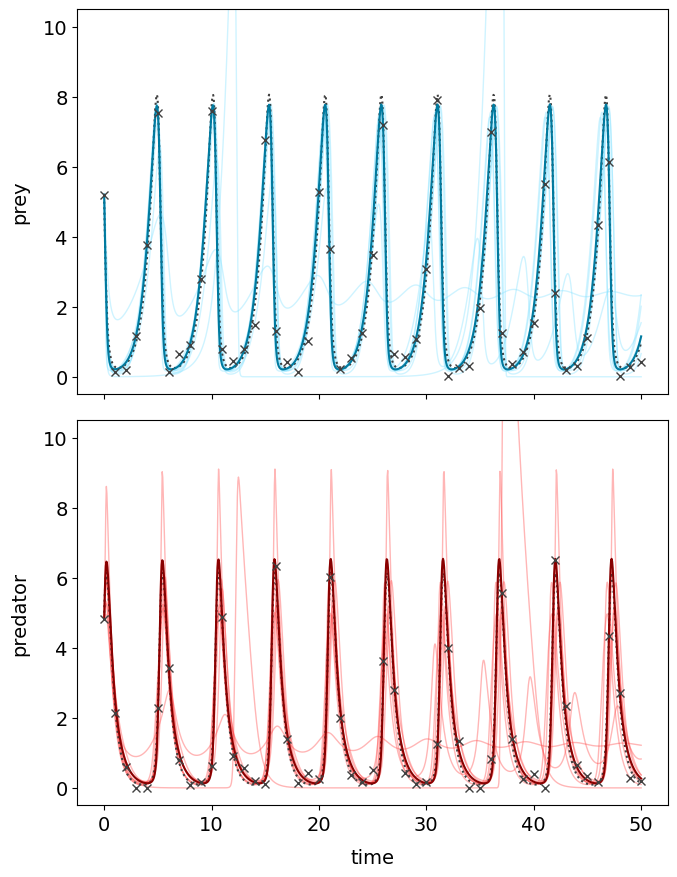

In [ ]:
rcParams["font.size"] = 14
rcParams["axes.labelpad"] = 10

sim.coordinates["time"] = np.linspace(0,20,1001)
sim.dispatch_constructor()
evaluator = sim.dispatch()
evaluator()

ts_real_sol, ys_real_sol = get_data(1, [1.3,0.9,0.8,1.8], 1, 5, 50, 1001, 0.0, key=jr.PRNGKey(0))

ys_obs = jnp.stack(jnp.array([sim.observations.prey.values, sim.observations.predator.values]), axis=1)

res = [evaluator._solver.standalone_solver(model, ts_real_sol, ys_obs[0], ()) for model in sim.inferer.optimized_models]

dervs = [jnp.array([model(None, y, (), None) for y in jnp.stack(jnp.array(res[i]), axis=1)]) for (i, model) in enumerate(sim.inferer.optimized_models)]

def loss(y_obs, y_pred):
    return (y_obs - y_pred)**2

def loss_func(y_obs, y_pred):
    return loss(jnp.where(jnp.isnan(y_obs), y_pred, y_obs), y_pred)

every = (int((1001 / 51) / 10) + 1) * 10

losses = [jnp.mean(loss_func(ys_obs, jnp.stack(jnp.array(result)[:,::every], axis=1))) for result in res]
best_model = sorted(zip(losses, [i for i in range(len(losses))]))[0][1]

fig, (ax_prey, ax_predator) = plt.subplots(nrows=2, figsize=(7,9), sharex=True)

ax_prey.plot(ts_real_sol, ys_real_sol[0,:,0], ":", c="#404040", zorder=9)
ax_prey.plot(sim.observations.time.values, sim.observations.prey.values, "x", c="#404040", zorder=11)
ax_predator.plot(ts_real_sol, ys_real_sol[0,:,1], ":", c="#404040", zorder=9)
ax_predator.plot(sim.observations.time.values, sim.observations.predator.values, "x", c="#404040", zorder=11)

for i in np.arange(len(sim.inferer.optimized_models)):
    if i == best_model:
        ax_prey.plot(ts_real_sol, res[i][0], c="#007A9F", zorder=10)
        ax_predator.plot(ts_real_sol, res[i][1], c="#890000", zorder=10)
    else:
        pass
        ax_prey.plot(ts_real_sol, res[i][0], c="#87E3FF", linewidth=1, alpha=0.4, zorder=0)
        ax_predator.plot(ts_real_sol, res[i][1], c="#FF4A4A", linewidth=1, alpha=0.4, zorder=0)

ax_prey.set_ylim((-0.5,10.5))
ax_predator.set_ylim((-0.5,10.5))
ax_prey.set_ylabel("prey abundance", fontsize=14)
ax_predator.set_ylabel("predator_abundance", fontsize=14)
ax_predator.set_xlabel("time", fontsize=14)

fig.tight_layout()
if nfic:
    fig.savefig("simple_cases/lotkasimple_nfic.png")
else:
    fig.savefig("simple_cases/lotkasimple.png")

In [9]:
string = ""

for i in range(len(sim.inferer.optimized_models)):
                    
    # print(str(j))

    try:
        psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.3))
        psmodel.fit(jnp.stack(jnp.array(res[i]), axis=1), t=sim.coordinates["time"], x_dot=dervs[i], feature_names=["X","Y"])
        eqs = psmodel.equations()
        string += str(losses[i]) + "\n" + eqs[0] + "\n" + eqs[1] + "\n"
    except ValueError as e:
        string += str(losses[i]) + "\n" + str(e) + "\n"
        print(e)

if nfic:
    with open(f"simple_cases/lotkasimple_nfic_SINDy.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/lotkasimple_SINDy.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.3) and eliminated all coefficients
  warnings.warn(


In [10]:
string = ""

for i in range(len(sim.inferer.optimized_models)):
                    
    # print(str(j))

    try:
        psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.5))
        psmodel.fit(jnp.stack(jnp.array(res[i]), axis=1), t=sim.coordinates["time"], x_dot=dervs[i], feature_names=["X","Y"])
        eqs = psmodel.equations()
        string += str(losses[i]) + "\n" + eqs[0] + "\n" + eqs[1] + "\n"
    except ValueError as e:
        string += str(losses[i]) + "\n" + str(e) + "\n"
        print(e)

if nfic:
    with open(f"simple_cases/lotkasimple_nfic_SINDy_0.5.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/lotkasimple_SINDy_0.5.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(


#### Variant 2: Load data

In [11]:
if nfic:
    idata = az.from_netcdf("simple_cases/lotkasimple_nfic.nc")
else:
    idata = az.from_netcdf("simple_cases/lotkasimple.nc")

model_key = jr.PRNGKey(0)
models = [Func({"alpha":jnp.array(1.3), "delta":idata.posterior.sel(draw=i).delta.values[0]},weights=idata.posterior.sel(draw=i).weights.values.tolist()[0],bias=idata.posterior.sel(draw=i).bias.values.tolist()[0],key=model_key) for i in np.arange(0, 10)]

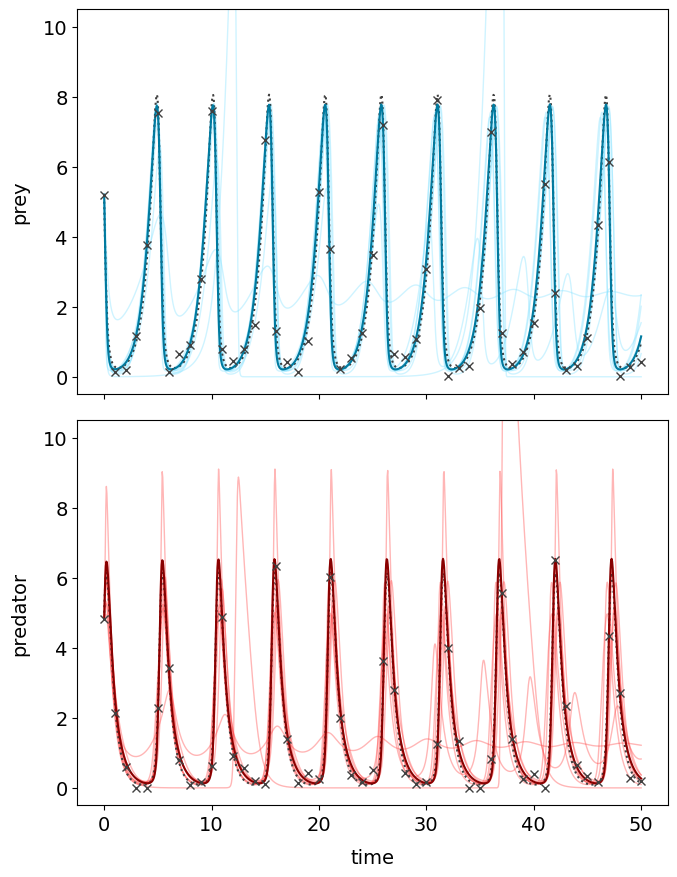

In [ ]:
rcParams["font.size"] = 14
rcParams["axes.labelpad"] = 10

sim.coordinates["time"] = np.linspace(0,20,1001)
sim.dispatch_constructor()
evaluator = sim.dispatch()
evaluator()

ts_real_sol, ys_real_sol = get_data(1, [1.3,0.9,0.8,1.8], 1, 5, 50, 1001, 0.0, key=jr.PRNGKey(0))

ys_obs = jnp.stack(jnp.array([sim.observations.prey.values, sim.observations.predator.values]), axis=1)

res = [evaluator._solver.standalone_solver(model, ts_real_sol, ys_obs[0], ()) for model in models]

dervs = [jnp.array([model(None, y, (), None) for y in jnp.stack(jnp.array(res[i]), axis=1)]) for (i, model) in enumerate(models)]

def loss(y_obs, y_pred):
    return (y_obs - y_pred)**2

def loss_func(y_obs, y_pred):
    return loss(jnp.where(jnp.isnan(y_obs), y_pred, y_obs), y_pred)

every = (int((1001 / 51) / 10) + 1) * 10

losses = [jnp.mean(loss_func(ys_obs, jnp.stack(jnp.array(result)[:,::every], axis=1))) for result in res]
best_model = sorted(zip(losses, [i for i in range(len(losses))]))[0][1]

fig, (ax_prey, ax_predator) = plt.subplots(nrows=2, figsize=(7,9), sharex=True)

ax_prey.plot(ts_real_sol, ys_real_sol[0,:,0], ":", c="#404040", zorder=9)
ax_prey.plot(sim.observations.time.values, sim.observations.prey.values, "x", c="#404040", zorder=11)
ax_predator.plot(ts_real_sol, ys_real_sol[0,:,1], ":", c="#404040", zorder=9)
ax_predator.plot(sim.observations.time.values, sim.observations.predator.values, "x", c="#404040", zorder=11)

for i in np.arange(len(models)):
    if i == best_model:
        ax_prey.plot(ts_real_sol, res[i][0], c="#007A9F", zorder=10)
        ax_predator.plot(ts_real_sol, res[i][1], c="#890000", zorder=10)
    else:
        pass
        ax_prey.plot(ts_real_sol, res[i][0], c="#87E3FF", linewidth=1, alpha=0.4, zorder=0)
        ax_predator.plot(ts_real_sol, res[i][1], c="#FF4A4A", linewidth=1, alpha=0.4, zorder=0)

ax_prey.set_ylim((-0.5,10.5))
ax_predator.set_ylim((-0.5,10.5))
ax_prey.set_ylabel("prey abundance", fontsize=14)
ax_predator.set_ylabel("predator abundance", fontsize=14)
ax_predator.set_xlabel("time", fontsize=14)

fig.tight_layout()
if nfic:
    fig.savefig("simple_cases/lotkasimple_nfic.png")
else:
    fig.savefig("simple_cases/lotkasimple.png")

In [13]:
string = ""

for i in range(len(models)):
                    
    # print(str(j))

    try:
        psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.3))
        psmodel.fit(jnp.stack(jnp.array(res[i]), axis=1), t=sim.coordinates["time"], x_dot=dervs[i], feature_names=["X","Y"])
        eqs = psmodel.equations()
        string += str(losses[i]) + "\n" + eqs[0] + "\n" + eqs[1] + "\n"
    except ValueError as e:
        string += str(losses[i]) + "\n" + str(e) + "\n"
        print(e)

if nfic:
    with open(f"simple_cases/lotkasimple_nfic_SINDy.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/lotkasimple_SINDy.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.3) and eliminated all coefficients
  warnings.warn(


In [14]:
string = ""

for i in range(len(models)):
                    
    # print(str(j))

    try:
        psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.5))
        psmodel.fit(jnp.stack(jnp.array(res[i]), axis=1), t=sim.coordinates["time"], x_dot=dervs[i], feature_names=["X","Y"])
        eqs = psmodel.equations()
        string += str(losses[i]) + "\n" + eqs[0] + "\n" + eqs[1] + "\n"
    except ValueError as e:
        string += str(losses[i]) + "\n" + str(e) + "\n"
        print(e)

if nfic:
    with open(f"simple_cases/lotkasimple_nfic_SINDy_0.5.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/lotkasimple_SINDy_0.5.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(


# Logistic growth

In [2]:
# Change this to determine which type of initial contions should be used
nfic = False

In [3]:
def _get_data(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (), minval=min, maxval=max)

    def f(t, y, args):
        dYdt = theta[0]*y - theta[0]/theta[1]*y**2
        return dYdt

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts)))
    ys += noisiness * noise
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

def _get_data2(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (), minval=min, maxval=max)

    def f(t, y, args):
        dYdt = theta[0]*y - theta[0]/theta[1]*y**2
        return dYdt

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts)))
    ys = ys.at[1:].set(ys[1:] + noisiness * noise[1:])
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data2(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data2(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

In [4]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest1D"

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func1D({"r":1.0},key=model_key)

# Define a solver
sim.solver = UDESolver

if not nfic:
    ts,ys = get_data(n, [1,2], 3, 0.1, 10, 51, 0.2, key=jr.PRNGKey(0))
else:
    ts,ys = get_data2(n, [1,2], 3, 0.1, 10, 51, 0.2, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data = xr.DataArray(ys, coords={"batch_id": datasets, "time": ts}).to_dataset(name="X")

# Add our dataset to the simulation
sim.observations = test_data

sim.config.model_parameters.r = Param(value=1, free=False)

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(101), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

MinMaxScaler(variable=X, min=9.99999993922529e-09, max=3.251249313354492)


C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.X = Datavariable(dimensions=['batch_id', 'time'] min=9.99999993922529e-09 max=3.251249313354492 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.X = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['dX_dt'] from the source code. Setting 'n_ode_states=1.
  warnings.warn(


#### Variant 1: Run inference process

In [5]:
sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 10
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 10
sim.config.inference_optax.multiple_runs_limit = 100
sim.config.inference_optax.time_limit = 600

sim.config.inference_optax.length_strategy = [0.1,0.2,0.5,1]
sim.config.inference_optax.lr_strategy = 0.001
sim.config.inference_optax.steps_strategy = [1000, 1000, 1000, 1000]
sim.config.inference_optax.clip_strategy = 0.0
sim.config.inference_optax.indepth = "off"

sim.set_inferer("optax")

In [6]:
sim.inferer.run()

10 of 10 runs completed: 100%|██████████| 40000/40000 [04:07<00:00, 161.66it/s, 0 unsuccessful runs so far]



run number	successful?	loss

run 1		yes		2.025829792022705
run 2		yes		0.04556930065155029
run 3		yes		0.0454503558576107
run 4		yes		0.04484173282980919
run 5		yes		0.04898529872298241
run 6		yes		0.04575897753238678
run 7		yes		0.04706289991736412
run 8		yes		0.044646844267845154
run 9		yes		0.9381143450737
run 10		yes		0.047301650047302246


In [7]:
if nfic:
    sim.inferer.store_results("simple_cases/logistic_growth_nfic.nc", "simple_cases/logistic_growth_nfic_f.nc")
else:
    sim.inferer.store_results("simple_cases/logistic_growth.nc", "simple_cases/logistic_growth_f.nc")

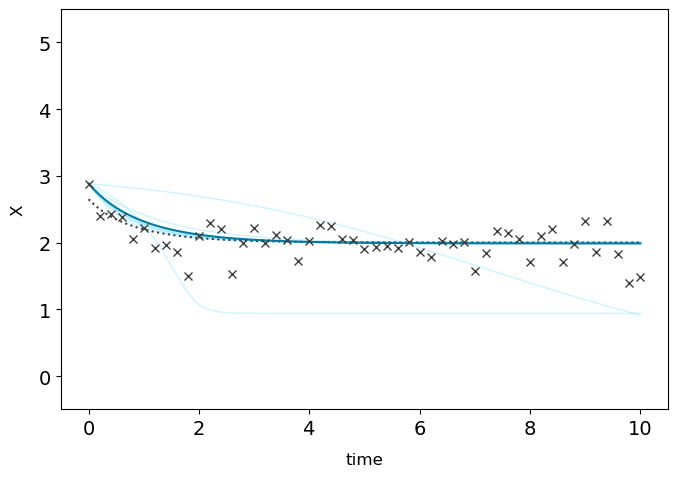

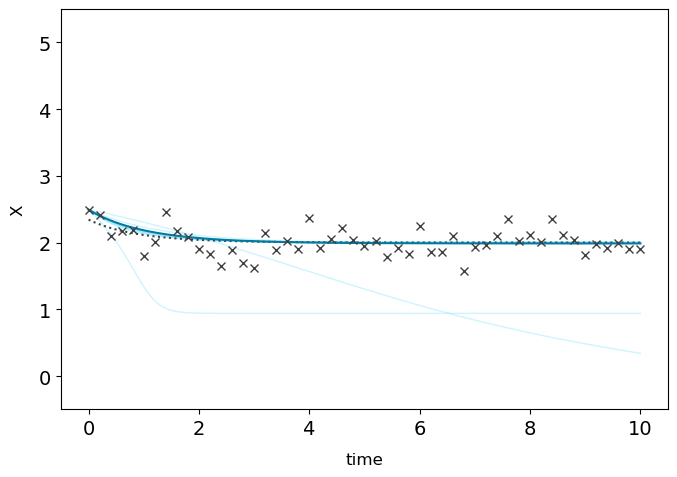

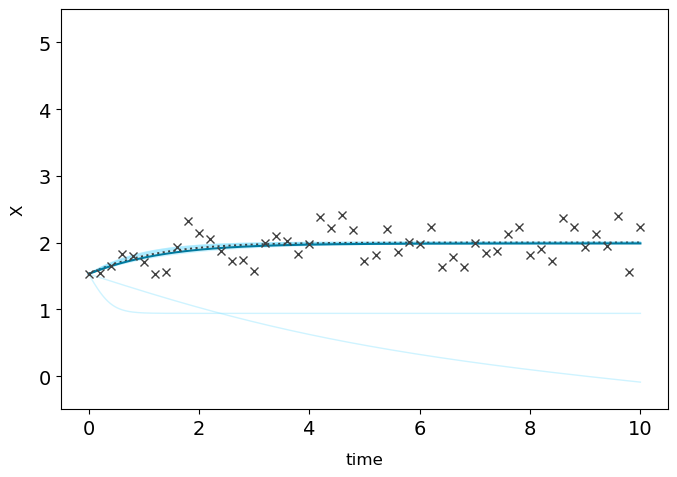

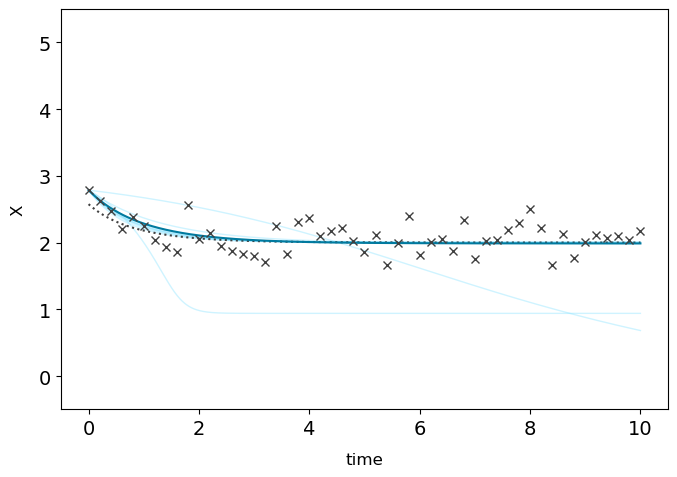

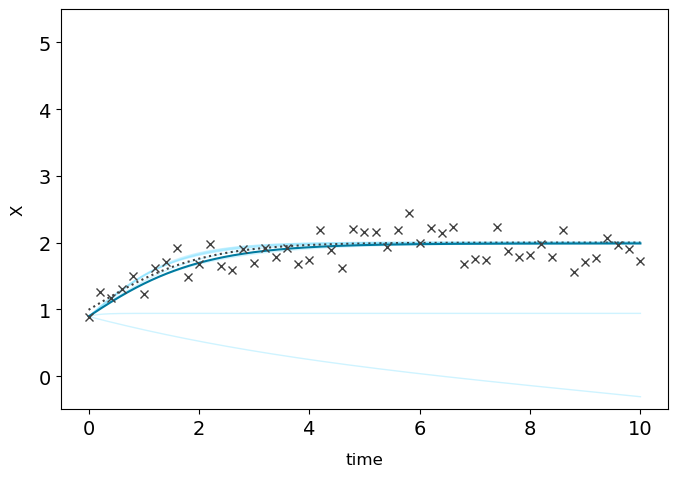

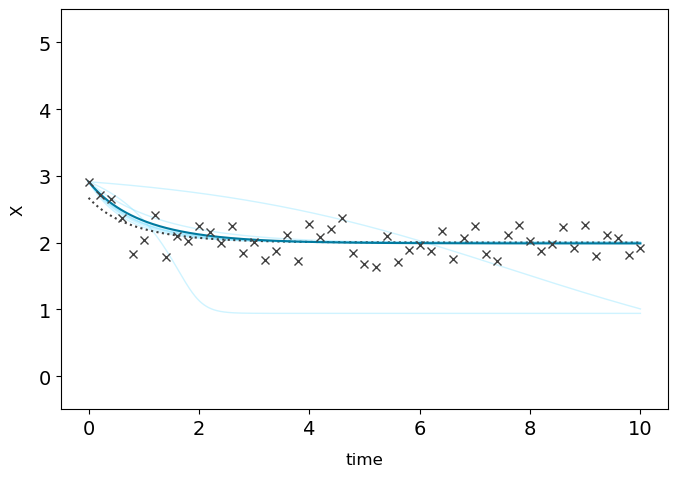

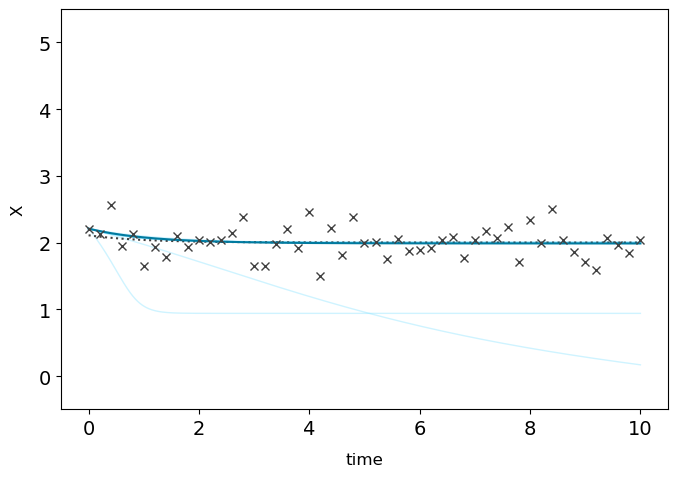

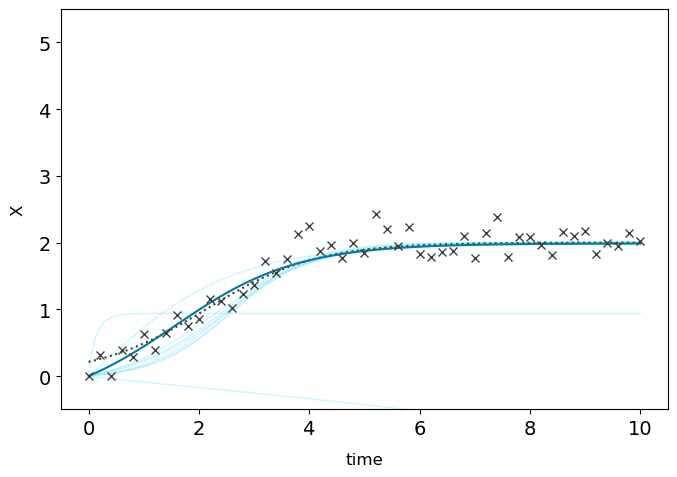

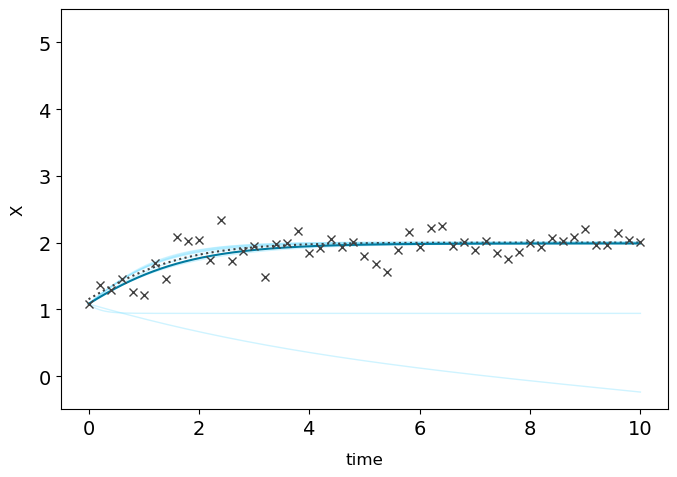

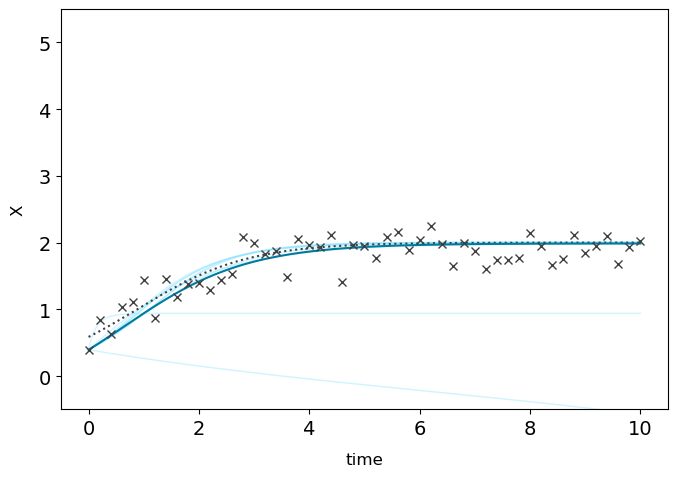

In [ ]:
rcParams["font.size"] = 14
rcParams["axes.labelpad"] = 10

sim.coordinates["time"] = np.linspace(0,20,1001)
sim.dispatch_constructor()
evaluator = sim.dispatch()
evaluator()

ts_real_sol, ys_real_sol = get_data(50, [1, 2], 3, 0.1, 10, 1001, 0, key=jr.PRNGKey(0))

res = [[evaluator._solver.standalone_solver(model, ts_real_sol, y[0], ()) for y in sim.observations.X.sel(batch_id=slice(40,49)).values] for model in sim.inferer.optimized_models]

dervs = [[jnp.array([model(None, jnp.array([y]), (), None) for y in ys[0]]) for ys in res[i]] for (i, model) in enumerate(sim.inferer.optimized_models)]

def loss(y_obs, y_pred):
    return (y_obs - y_pred)**2

def loss_func(y_obs, y_pred):
    return loss(jnp.where(jnp.isnan(y_obs), y_pred, y_obs), y_pred)

every = (int((1001 / 51) / 10) + 1) * 10

losses = [jnp.mean(loss_func(sim.observations.X.sel(batch_id=slice(40,49)).values, jnp.array(result)[:,0,::every])) for result in res]
best_model = sorted(zip(losses, [i for i in range(len(losses))]))[0][1]

for time_series in jnp.arange(0,10):

    fig, ax = plt.subplots(figsize = (7,5))

    ax.plot(ts_real_sol, ys_real_sol[40+time_series], ":", c="#404040", zorder=9)
    ax.plot(sim.observations.time.values, sim.observations.X.sel(batch_id=slice(40,49)).values[time_series], "x", c="#404040", zorder=11)

    for i in np.arange(len(sim.inferer.optimized_models)):
        if i == best_model:
            ax.plot(ts_real_sol, res[i][time_series][0], c="#007A9F", zorder=10)
        else:
            pass
            ax.plot(ts_real_sol, res[i][time_series][0], c="#87E3FF", linewidth=1, alpha=0.4, zorder=0)

    ax.set_ylim((-0.5,5.5))
    ax.set_ylabel("X", fontsize=14)
    ax.set_xlabel("time", fontsize=14)

    fig.tight_layout()
    if nfic:
        fig.savefig(f"simple_cases/logistic_growth_nfic_{time_series}.png")
    else:
        fig.savefig(f"simple_cases/logistic_growth_{time_series}.png")

In [9]:
string = ""

for i in range(len(sim.inferer.optimized_models)):

    string += "loss: " + str(losses[i]) + "\n"

    for j in range(10):

        try:
            psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.2))
            psmodel.fit(np.array(res)[i,j,0], t=sim.coordinates["time"], x_dot=dervs[i][j].T[0], feature_names=["X"])
            eqs = psmodel.equations()
            string += eqs[0] + "\n"
        except ValueError as e:
            print(e)

    psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.2))
    psmodel.fit([x for x in np.array(res)[i,:,0]], t=sim.coordinates["time"], x_dot=[x for x in np.array(dervs)[i,:,:,0]], feature_names=["X"])
    eqs = psmodel.equations()
    string += "pooled: " + eqs[0] + "\n"

if nfic:
    with open(f"simple_cases/logistic_growth_nfic_SINDy.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/logistic_growth_SINDy.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.2) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.2) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\

In [10]:
string = ""

for i in range(len(sim.inferer.optimized_models)):

    string += "loss: " + str(losses[i]) + "\n"

    for j in range(10):

        try:
            psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.5))
            psmodel.fit(np.array(res)[i,j,0], t=sim.coordinates["time"], x_dot=dervs[i][j].T[0], feature_names=["X"])
            eqs = psmodel.equations()
            string += eqs[0] + "\n"
        except ValueError as e:
            print(e)

    psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.5))
    psmodel.fit([x for x in np.array(res)[i,:,0]], t=sim.coordinates["time"], x_dot=[x for x in np.array(dervs)[i,:,:,0]], feature_names=["X"])
    eqs = psmodel.equations()
    string += "pooled: " + eqs[0] + "\n"

if nfic:
    with open(f"simple_cases/logistic_growth_nfic_SINDy_0.3.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/logistic_growth_SINDy_0.3.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\

#### Variant 2: Load data

In [5]:
if nfic:
    idata = az.from_netcdf("simple_cases/logistic_growth_nfic.nc")
else:
    idata = az.from_netcdf("simple_cases/logistic_growth.nc")

model_key = jr.PRNGKey(0)
models = [Func1D({"r":jnp.array(1.0)},weights=idata.posterior.sel(draw=i).weights.values.tolist()[0],bias=idata.posterior.sel(draw=i).bias.values.tolist()[0],key=model_key) for i in np.arange(0, 10)]

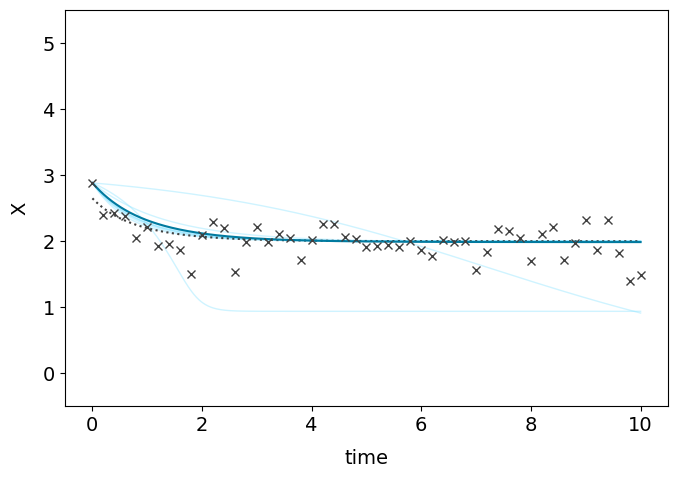

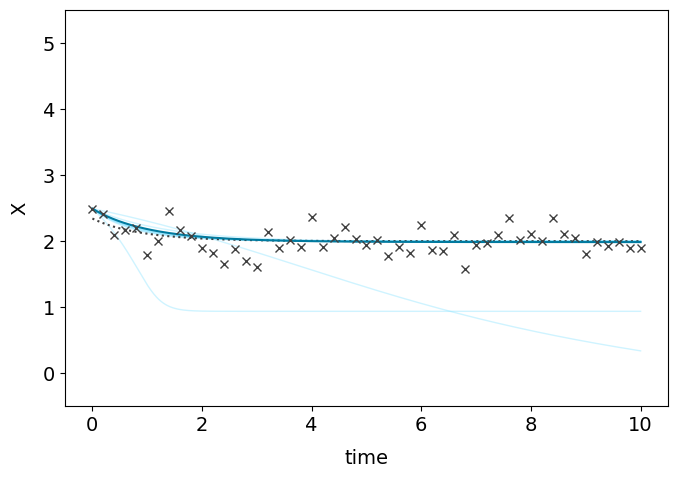

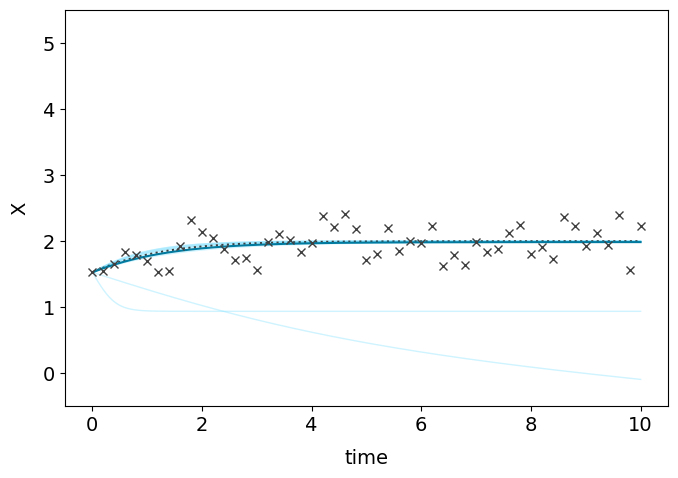

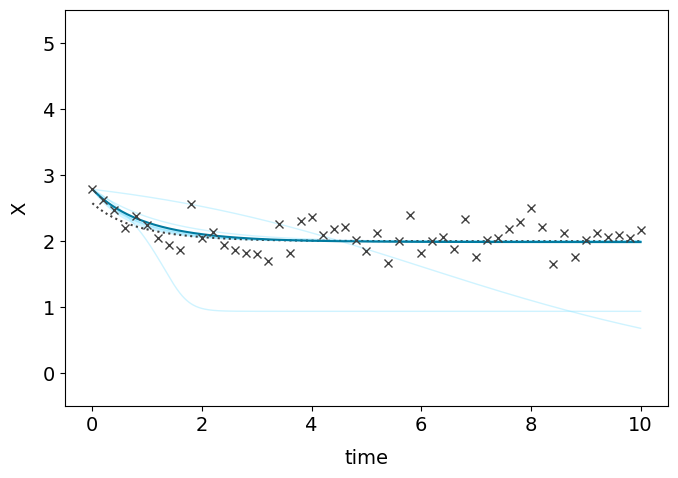

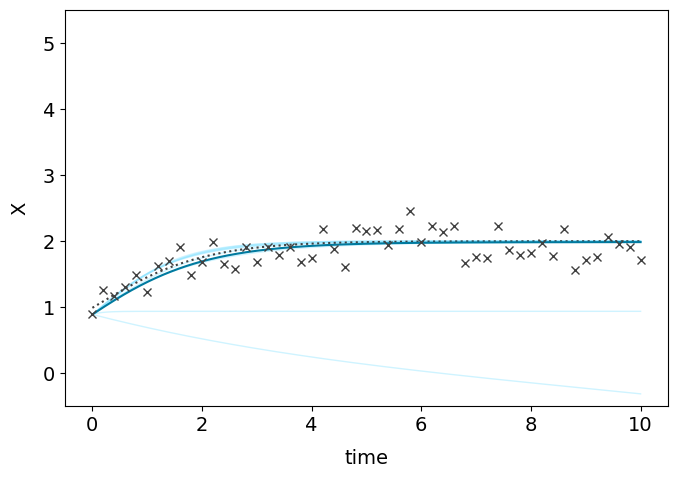

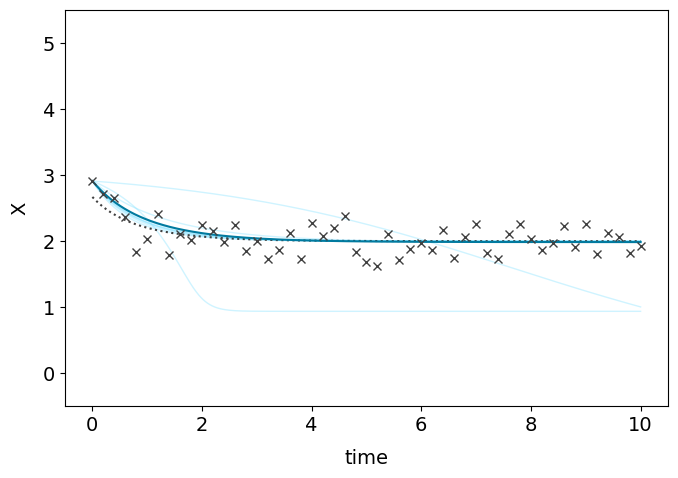

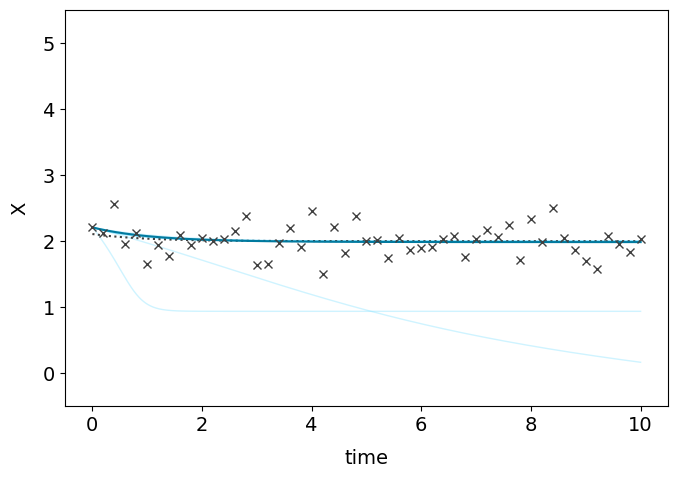

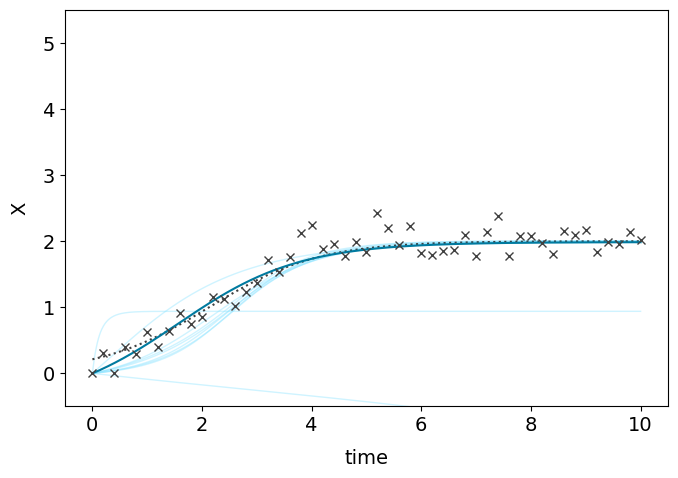

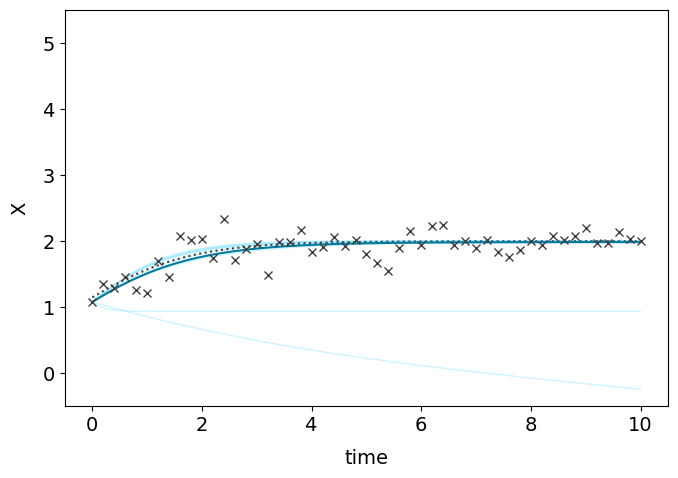

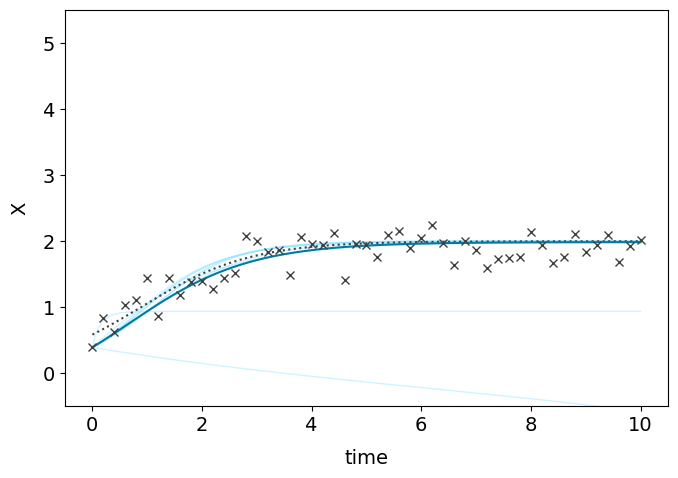

In [6]:
rcParams["font.size"] = 14
rcParams["axes.labelpad"] = 10

sim.coordinates["time"] = np.linspace(0,20,1001)
sim.dispatch_constructor()
evaluator = sim.dispatch()
evaluator()

ts_real_sol, ys_real_sol = get_data(50, [1, 2], 3, 0.1, 10, 1001, 0, key=jr.PRNGKey(0))

res = [[evaluator._solver.standalone_solver(model, ts_real_sol, y[0], ()) for y in sim.observations.X.sel(batch_id=slice(40,49)).values] for model in models]

dervs = [[jnp.array([model(None, jnp.array([y]), (), None) for y in ys[0]]) for ys in res[i]] for (i, model) in enumerate(models)]

def loss(y_obs, y_pred):
    return (y_obs - y_pred)**2

def loss_func(y_obs, y_pred):
    return loss(jnp.where(jnp.isnan(y_obs), y_pred, y_obs), y_pred)

every = (int((1001 / 51) / 10) + 1) * 10

losses = [jnp.mean(loss_func(sim.observations.X.sel(batch_id=slice(40,49)).values, jnp.array(result)[:,0,::every])) for result in res]
best_model = sorted(zip(losses, [i for i in range(len(losses))]))[0][1]

for time_series in jnp.arange(0,10):

    fig, ax = plt.subplots(figsize = (7,5))

    ax.plot(ts_real_sol, ys_real_sol[40+time_series], ":", c="#404040", zorder=9)
    ax.plot(sim.observations.time.values, sim.observations.X.sel(batch_id=slice(40,49)).values[time_series], "x", c="#404040", zorder=11)

    for i in np.arange(len(models)):
        if i == best_model:
            ax.plot(ts_real_sol, res[i][time_series][0], c="#007A9F", zorder=10)
        else:
            pass
            ax.plot(ts_real_sol, res[i][time_series][0], c="#87E3FF", linewidth=1, alpha=0.4, zorder=0)

    ax.set_ylim((-0.5,5.5))
    ax.set_ylabel("X", fontsize=14)
    ax.set_xlabel("time", fontsize=14)

    fig.tight_layout()
    if nfic:
        fig.savefig(f"simple_cases/logistic_growth_nfic_{time_series}.png")
    else:
        fig.savefig(f"simple_cases/logistic_growth_{time_series}.png")

In [7]:
import pysindy as ps

string = ""

for i in range(len(models)):

    string += "loss: " + str(losses[i]) + "\n"

    for j in range(10):

        try:
            psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.2))
            psmodel.fit(np.array(res)[i,j,0], t=sim.coordinates["time"], x_dot=dervs[i][j].T[0], feature_names=["X"])
            eqs = psmodel.equations()
            string += eqs[0] + "\n"
        except ValueError as e:
            print(e)

    psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.2))
    psmodel.fit([x for x in np.array(res)[i,:,0]], t=sim.coordinates["time"], x_dot=[x for x in np.array(dervs)[i,:,:,0]], feature_names=["X"])
    eqs = psmodel.equations()
    string += "pooled: " + eqs[0] + "\n"

if nfic:
    with open(f"simple_cases/logistic_growth_nfic_SINDy.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/logistic_growth_SINDy.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.2) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.2) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\

In [8]:
import pysindy as ps

string = ""

for i in range(len(models)):

    string += "loss: " + str(losses[i]) + "\n"

    for j in range(10):

        try:
            psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.5))
            psmodel.fit(np.array(res)[i,j,0], t=sim.coordinates["time"], x_dot=dervs[i][j].T[0], feature_names=["X"])
            eqs = psmodel.equations()
            string += eqs[0] + "\n"
        except ValueError as e:
            print(e)

    psmodel = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=0.5))
    psmodel.fit([x for x in np.array(res)[i,:,0]], t=sim.coordinates["time"], x_dot=[x for x in np.array(dervs)[i,:,:,0]], feature_names=["X"])
    eqs = psmodel.equations()
    string += "pooled: " + eqs[0] + "\n"

if nfic:
    with open(f"simple_cases/logistic_growth_nfic_SINDy_0.3.txt","w") as variable_name:
        variable_name.write(string)
else:
    with open(f"simple_cases/logistic_growth_SINDy_0.3.txt","w") as variable_name:
        variable_name.write(string)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\utils\axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.5) and eliminated all coefficients
  warnings.warn(
c:\Users\Markus\anaconda3\